# Data Understanding - Conversation Transcripts & Objections
## Avatar Project - TDSP Methodology

**Dataset #4:** Conversation Transcripts & Objections Database

**Intérêt:** CRUCIAL pour DSO 1 (entraînement modèles NLP d'évaluation), DSO 2 (base de connaissances objections), et DSO 3 (analytics patterns objections)

---
## 1. Load Data

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv('conversation_transcripts.csv', encoding='utf-8-sig')

print(f"Dataset loaded: {df.shape[0]} conversations, {df.shape[1]} columns")

Dataset loaded: 400 conversations, 18 columns


---
## 2. First Look at Data

In [8]:
# Show first 3 rows (limited columns for readability)
display_cols = ['conversation_id', 'rep_id', 'product', 'objection_type', 'response_quality', 'overall_score', 'outcome']
df[display_cols].head(3)

,conversation_id,rep_id,product,objection_type,response_quality,overall_score,outcome
0,CONV00100,REP022,OLIGOVIT Trio,Marque inconnue,Bon,6.5,Intérêt Modéré
1,CONV00364,REP017,PHYTOFANE Lotion anti chute,Posologie complexe,Bon,6.2,Demande info
2,CONV00075,REP011,Vitonic Tonus,Efficacité douteuse,Excellent,9.5,Intérêt Fort


In [10]:
# Show dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   conversation_id              400 non-null    object 
 1   rep_id                       400 non-null    object 
 2   client_id                    400 non-null    object 
 3   date                         400 non-null    object 
 4   product                      400 non-null    object 
 5   objection_type               400 non-null    object 
 6   objection_text               400 non-null    object 
 7   rep_response                 400 non-null    object 
 8   response_quality             400 non-null    object 
 9   scientific_accuracy_score    400 non-null    float64
 10  communication_clarity_score  400 non-null    float64
 11  objection_handling_score     400 non-null    float64
 12  overall_score                400 non-null    float64
 13  client_sentiment    

In [12]:
# Show column names
print("Columns:")
for col in df.columns:
    print(f"  - {col}")

Columns:
  - conversation_id
  - rep_id
  - client_id
  - date
  - product
  - objection_type
  - objection_text
  - rep_response
  - response_quality
  - scientific_accuracy_score
  - communication_clarity_score
  - objection_handling_score
  - overall_score
  - client_sentiment
  - conversation_duration_sec
  - outcome
  - conversation_transcript
  - skill_tags


### Column Descriptions:

| Column | Description |
|--------|-------------|
| **conversation_id** | Unique conversation identifier |
| **rep_id** | Medical representative ID |
| **client_id** | Client (pharmacy/doctor) ID |
| **date** | Date of conversation |
| **product** | Product discussed |
| **objection_type** | Type of objection raised |
| **objection_text** | Exact objection from client |
| **rep_response** | Representative's response |
| **response_quality** | Quality rating (Excellent/Bon/Faible) |
| **scientific_accuracy_score** | Scientific precision score (0-10) |
| **communication_clarity_score** | Communication clarity score (0-10) |
| **objection_handling_score** | Objection handling score (0-10) |
| **overall_score** | Average of three scores |
| **client_sentiment** | Client sentiment (Positif/Neutre/Négatif) |
| **conversation_duration_sec** | Duration in seconds |
| **outcome** | Conversation outcome |
| **conversation_transcript** | Full conversation text |
| **skill_tags** | Skill/competency tags |

---
## 3. Check Data Quality

In [16]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(1))

Missing Values:
conversation_id                0
rep_id                         0
client_id                      0
date                           0
product                        0
objection_type                 0
objection_text                 0
rep_response                   0
response_quality               0
scientific_accuracy_score      0
communication_clarity_score    0
objection_handling_score       0
overall_score                  0
client_sentiment               0
conversation_duration_sec      0
outcome                        0
conversation_transcript        0
skill_tags                     0
dtype: int64

Missing percentage:
conversation_id                0.0
rep_id                         0.0
client_id                      0.0
date                           0.0
product                        0.0
objection_type                 0.0
objection_text                 0.0
rep_response                   0.0
response_quality               0.0
scientific_accuracy_score      0.0
commun

In [18]:
# Check duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate conversation IDs: {df['conversation_id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate conversation IDs: 0


---
## 4. Analyze Objection Types

In [21]:
# Objection types distribution
print("Objection Types:")
print(df['objection_type'].value_counts())
print(f"\nTotal unique objection types: {df['objection_type'].nunique()}")

Objection Types:
objection_type
Efficacité douteuse    58
Concurrence            56
Prix élevé             56
Stock suffisant        52
Effets secondaires     49
Marque inconnue        48
Demande faible         42
Posologie complexe     39
Name: count, dtype: int64

Total unique objection types: 8


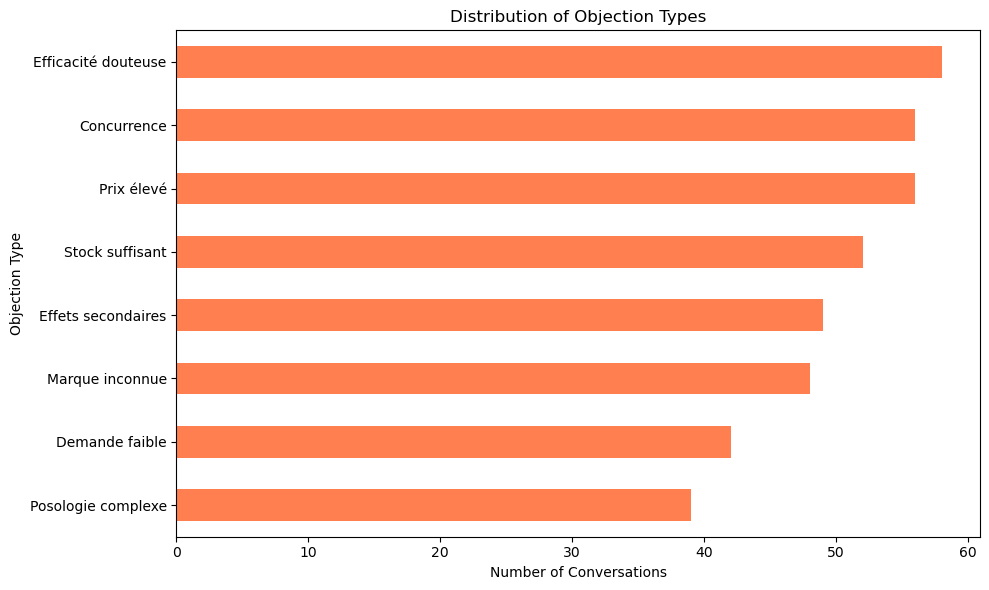

In [23]:
# Visualize objection types
df['objection_type'].value_counts().plot(kind='barh', color='coral', figsize=(10,6))
plt.title('Distribution of Objection Types')
plt.xlabel('Number of Conversations')
plt.ylabel('Objection Type')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Analyze Response Quality

In [26]:
# Response quality distribution
print("Response Quality:")
print(df['response_quality'].value_counts())
print(f"\nPercentages:")
print((df['response_quality'].value_counts() / len(df) * 100).round(1))

Response Quality:
response_quality
Bon          191
Excellent    131
Faible        78
Name: count, dtype: int64

Percentages:
response_quality
Bon          47.8
Excellent    32.8
Faible       19.5
Name: count, dtype: float64


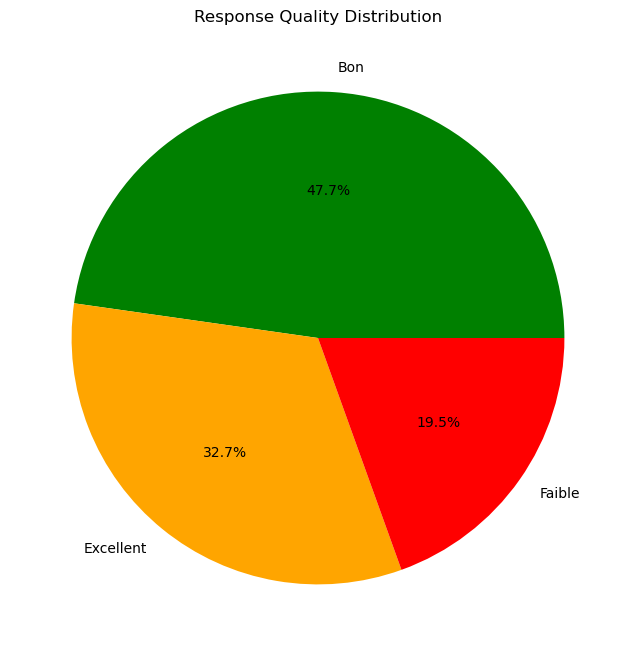

In [28]:
# Visualize response quality
colors = ['green', 'orange', 'red']
df['response_quality'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=colors, figsize=(8,8))
plt.title('Response Quality Distribution')
plt.ylabel('')
plt.show()

---
## 6. Analyze Performance Scores

In [31]:
# Score statistics
score_cols = ['scientific_accuracy_score', 'communication_clarity_score', 
              'objection_handling_score', 'overall_score']

print("Performance Scores Statistics:")
print(df[score_cols].describe())

Performance Scores Statistics:
       scientific_accuracy_score  communication_clarity_score  \
count                 400.000000                   400.000000   
mean                    7.186000                     7.220750   
std                     1.686851                     1.682549   
min                     3.000000                     3.000000   
25%                     6.200000                     6.300000   
50%                     7.300000                     7.300000   
75%                     8.500000                     8.500000   
max                     9.900000                    10.000000   

       objection_handling_score  overall_score  
count                400.000000     400.000000  
mean                   6.515000       6.974000  
std                    2.031426       1.721375  
min                    2.100000       3.000000  
25%                    5.200000       6.300000  
50%                    6.250000       6.800000  
75%                    8.400000       8.

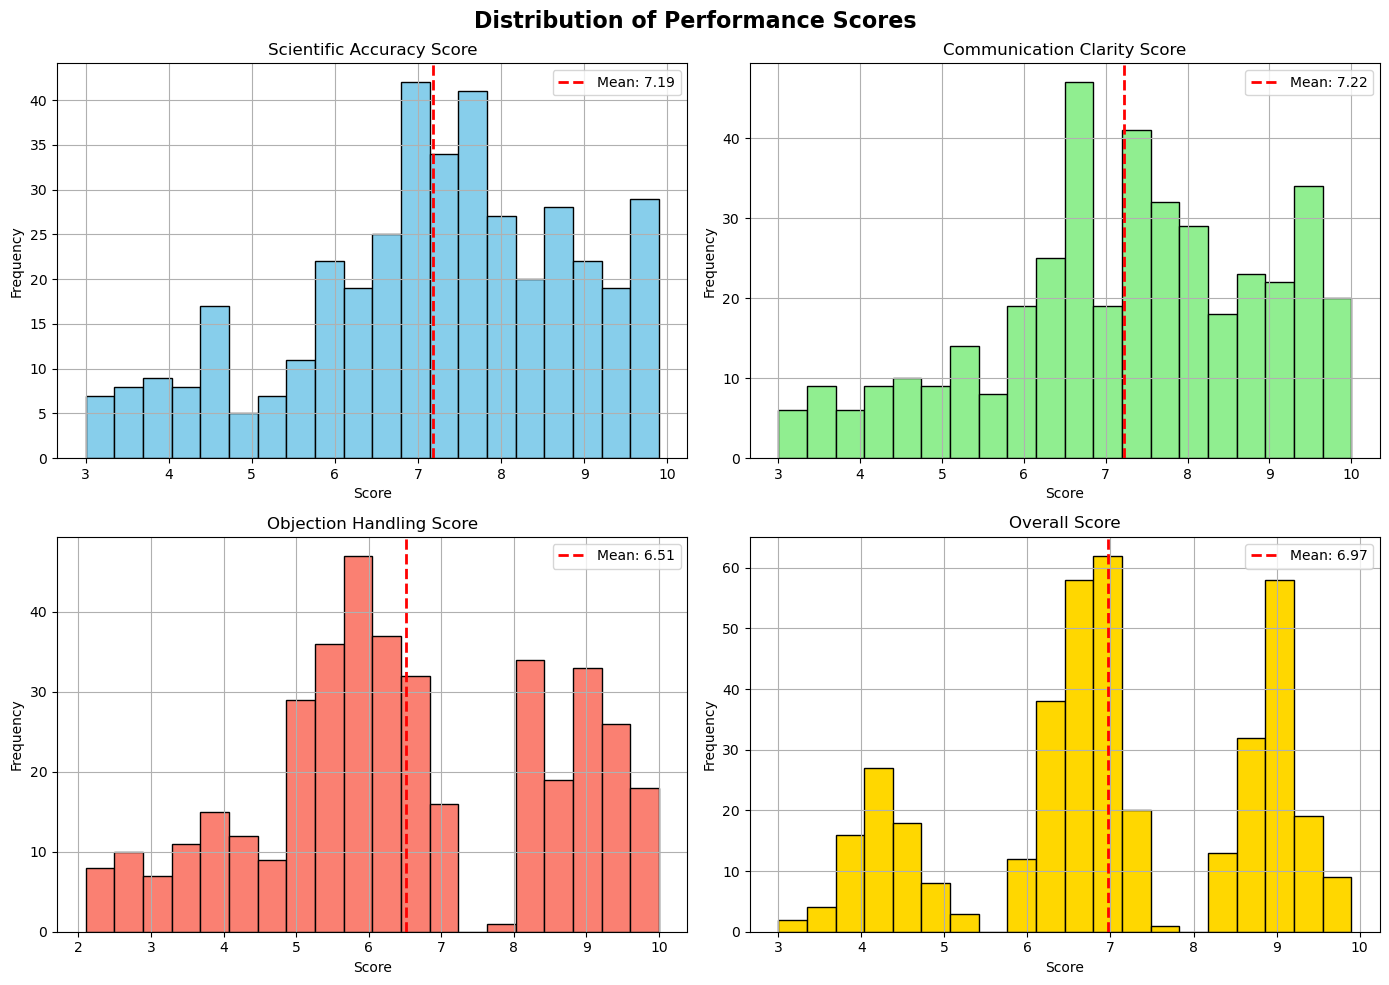

In [33]:
# Visualize score distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Performance Scores', fontsize=16, fontweight='bold')

colors = ['skyblue', 'lightgreen', 'salmon', 'gold']
for idx, col in enumerate(score_cols):
    ax = axes[idx // 2, idx % 2]
    df[col].hist(bins=20, color=colors[idx], edgecolor='black', ax=ax)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

In [34]:
# Average scores by response quality
print("\nAverage Scores by Response Quality:")
scores_by_quality = df.groupby('response_quality')[score_cols].mean().round(2)
print(scores_by_quality)


Average Scores by Response Quality:
                  scientific_accuracy_score  communication_clarity_score  \
response_quality                                                           
Bon                                    7.04                         7.02   
Excellent                              8.98                         9.05   
Faible                                 4.53                         4.62   

                  objection_handling_score  overall_score  
response_quality                                           
Bon                                   6.00           6.69  
Excellent                             8.98           9.00  
Faible                                3.64           4.27  


---
## 7. Analyze Client Sentiment

In [38]:
# Sentiment distribution
print("Client Sentiment:")
print(df['client_sentiment'].value_counts())
print(f"\nPercentages:")
print((df['client_sentiment'].value_counts() / len(df) * 100).round(1))

Client Sentiment:
client_sentiment
Neutre     191
Positif    115
Négatif     94
Name: count, dtype: int64

Percentages:
client_sentiment
Neutre     47.8
Positif    28.7
Négatif    23.5
Name: count, dtype: float64


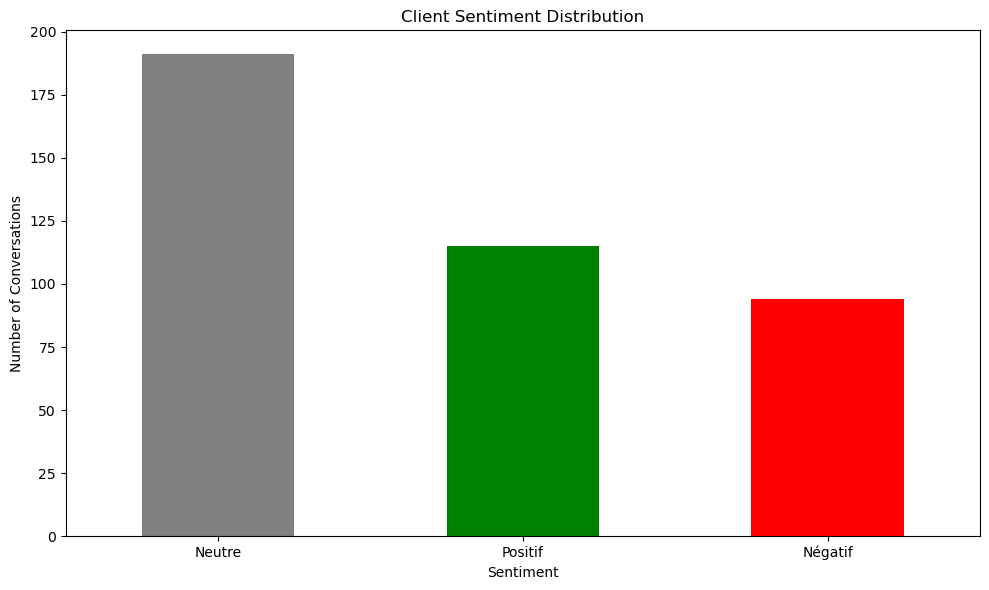

In [40]:
# Visualize sentiment
sentiment_colors = {'Positif': 'green', 'Neutre': 'gray', 'Négatif': 'red'}
sentiment_counts = df['client_sentiment'].value_counts()
colors_list = [sentiment_colors[s] for s in sentiment_counts.index]

sentiment_counts.plot(kind='bar', color=colors_list, figsize=(10,6))
plt.title('Client Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Conversations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
# Sentiment by response quality
print("\nSentiment by Response Quality:")
sentiment_quality = pd.crosstab(df['response_quality'], df['client_sentiment'])
print(sentiment_quality)


Sentiment by Response Quality:
client_sentiment  Neutre  Négatif  Positif
response_quality                          
Bon                   93       48       50
Excellent             59       33       39
Faible                39       13       26


---
## 8. Analyze Outcomes

In [45]:
# Outcome distribution
print("Conversation Outcomes:")
print(df['outcome'].value_counts())
print(f"\nPercentages:")
print((df['outcome'].value_counts() / len(df) * 100).round(1))

Conversation Outcomes:
outcome
Intérêt Modéré             72
Demande info               60
À rappeler                 59
Rendez-vous futur          51
Intérêt Fort               42
Commande                   38
Objections non résolues    28
Pas intéressé              26
Refus                      24
Name: count, dtype: int64

Percentages:
outcome
Intérêt Modéré             18.0
Demande info               15.0
À rappeler                 14.8
Rendez-vous futur          12.8
Intérêt Fort               10.5
Commande                    9.5
Objections non résolues     7.0
Pas intéressé               6.5
Refus                       6.0
Name: count, dtype: float64


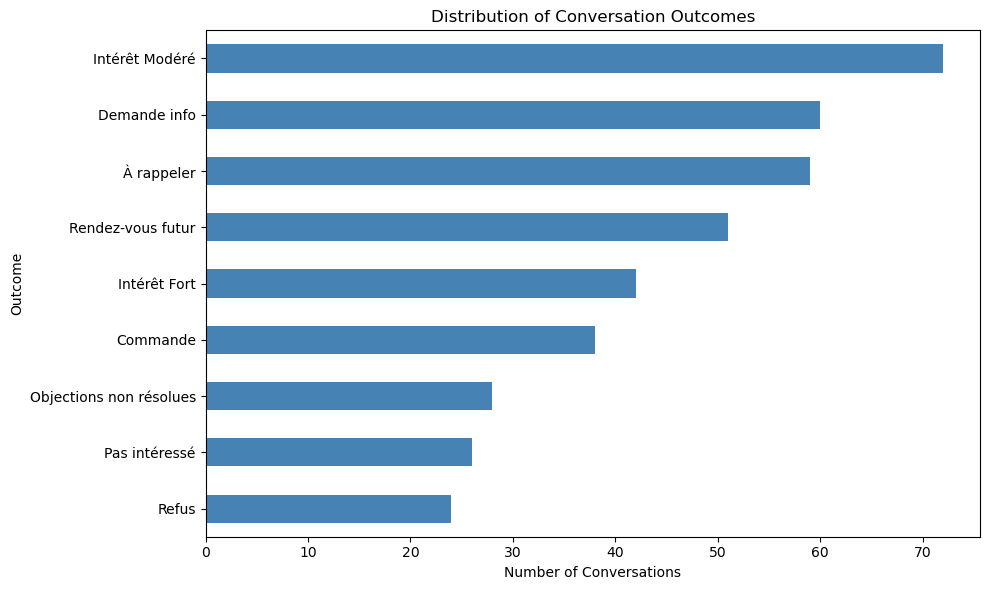

In [47]:
# Visualize outcomes
df['outcome'].value_counts().plot(kind='barh', color='steelblue', figsize=(10,6))
plt.title('Distribution of Conversation Outcomes')
plt.xlabel('Number of Conversations')
plt.ylabel('Outcome')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [49]:
# Outcome by response quality
print("\nOutcome by Response Quality:")
outcome_quality = pd.crosstab(df['response_quality'], df['outcome'])
print(outcome_quality)


Outcome by Response Quality:
outcome           Commande  Demande info  Intérêt Fort  Intérêt Modéré  \
response_quality                                                         
Bon                      0            60             0              72   
Excellent               38             0            42               0   
Faible                   0             0             0               0   

outcome           Objections non résolues  Pas intéressé  Refus  \
response_quality                                                  
Bon                                     0              0      0   
Excellent                               0              0      0   
Faible                                 28             26     24   

outcome           Rendez-vous futur  À rappeler  
response_quality                                 
Bon                               0          59  
Excellent                        51           0  
Faible                            0           0  


---
## 9. Analyze Objection-Product Patterns

In [52]:
# Products discussed
print("Products in Conversations:")
print(df['product'].value_counts())

Products in Conversations:
product
Echinacée, Zinc, Vit.C         58
PHYTOFANE Lotion anti chute    54
LV Vitamine A                  52
OLIGOVIT Trio                  51
LV Fersang junior              51
Omevie Omega 3 – 1000          47
LV CYSPROTECT                  47
Vitonic Tonus                  40
Name: count, dtype: int64


In [54]:
# Most common objections by product (top 3 products)
top_products = df['product'].value_counts().head(3).index

print("\nMost Common Objections by Top Products:")
for product in top_products:
    print(f"\n{product}:")
    objections = df[df['product'] == product]['objection_type'].value_counts().head(3)
    print(objections)


Most Common Objections by Top Products:

Echinacée, Zinc, Vit.C:
objection_type
Efficacité douteuse    13
Concurrence            10
Prix élevé              9
Name: count, dtype: int64

PHYTOFANE Lotion anti chute:
objection_type
Effets secondaires     8
Efficacité douteuse    8
Stock suffisant        8
Name: count, dtype: int64

LV Vitamine A:
objection_type
Concurrence            9
Efficacité douteuse    8
Prix élevé             7
Name: count, dtype: int64


In [56]:
# Success rate by objection type
print("\nSuccess Rate by Objection Type:")
# Define success as 'Excellent' or 'Bon' response
df['success'] = df['response_quality'].isin(['Excellent', 'Bon'])
success_by_objection = df.groupby('objection_type')['success'].mean().sort_values(ascending=False) * 100
print(success_by_objection.round(1))


Success Rate by Objection Type:
objection_type
Prix élevé             83.9
Efficacité douteuse    82.8
Concurrence            82.1
Demande faible         81.0
Effets secondaires     79.6
Posologie complexe     79.5
Marque inconnue        79.2
Stock suffisant        75.0
Name: success, dtype: float64


---
## 10. Analyze Conversation Duration

In [59]:
# Convert seconds to minutes
df['duration_minutes'] = df['conversation_duration_sec'] / 60

print("Conversation Duration Statistics (minutes):")
print(df['duration_minutes'].describe())

Conversation Duration Statistics (minutes):
count    400.000000
mean       6.060875
std        2.269228
min        2.000000
25%        4.062500
50%        6.058333
75%        8.020833
max        9.983333
Name: duration_minutes, dtype: float64


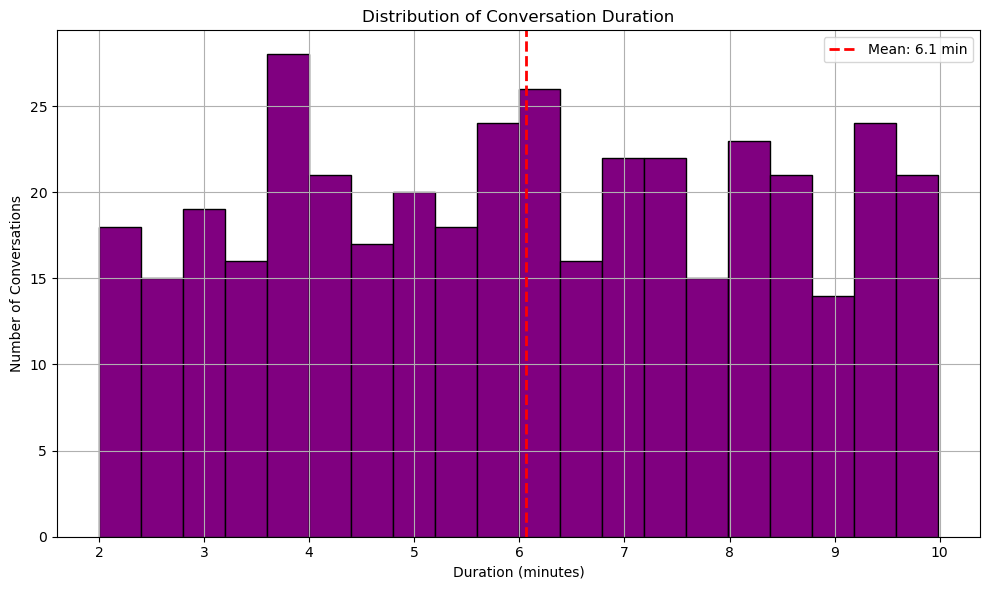

In [61]:
# Duration distribution
df['duration_minutes'].hist(bins=20, color='purple', edgecolor='black', figsize=(10,6))
plt.title('Distribution of Conversation Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Conversations')
plt.axvline(df['duration_minutes'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {df["duration_minutes"].mean():.1f} min')
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
# Duration by response quality
print("\nAverage Duration by Response Quality:")
duration_by_quality = df.groupby('response_quality')['duration_minutes'].mean().sort_values(ascending=False)
print(duration_by_quality.round(1))


Average Duration by Response Quality:
response_quality
Faible       6.4
Bon          6.1
Excellent    5.7
Name: duration_minutes, dtype: float64


---
## 11. Analyze Skill Tags

In [66]:
# Extract all skill tags
all_tags = []
for tags in df['skill_tags']:
    for tag in tags.split(', '):
        all_tags.append(tag.strip())

from collections import Counter
tag_counts = Counter(all_tags)

print("Skill Tags Distribution:")
for tag, count in tag_counts.most_common():
    print(f"  {tag}: {count}")

Skill Tags Distribution:
  Argumentation correcte: 191
  Informations basiques: 191
  Argumentation solide: 131
  Réponse scientifique: 131
  Empathie client: 131
  Réponse vague: 78
  Manque de préparation: 78


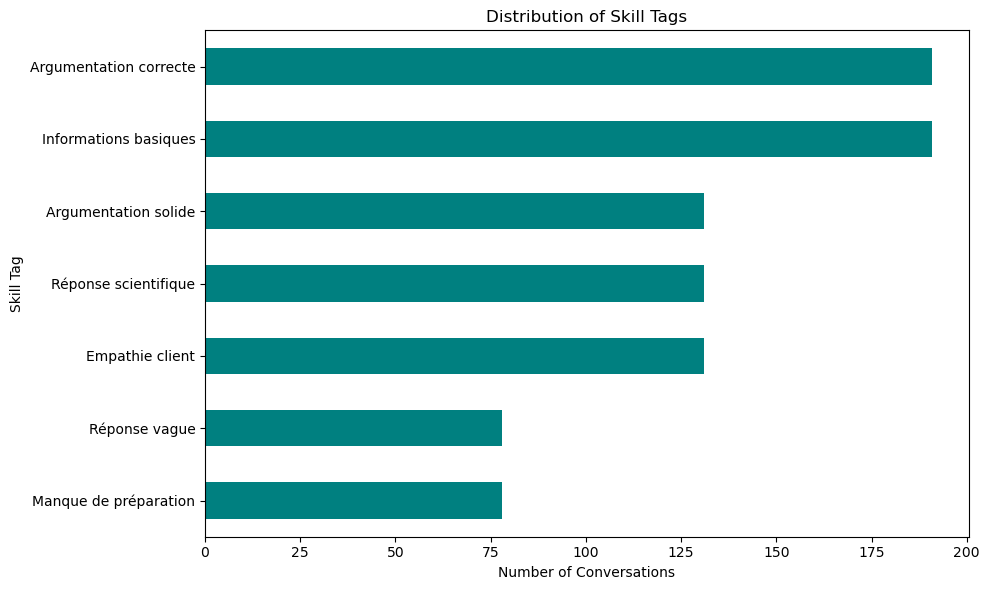

In [68]:
# Visualize skill tags
tag_df = pd.DataFrame.from_dict(tag_counts, orient='index', columns=['Count'])
tag_df.plot(kind='barh', color='teal', legend=False, figsize=(10,6))
plt.title('Distribution of Skill Tags')
plt.xlabel('Number of Conversations')
plt.ylabel('Skill Tag')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 12. Text Analysis - Sample Conversations

In [71]:
# Show sample excellent response
print("EXAMPLE 1: Excellent Response")
print("="*80)
excellent_sample = df[df['response_quality'] == 'Excellent'].iloc[0]
print(f"Product: {excellent_sample['product']}")
print(f"Objection Type: {excellent_sample['objection_type']}")
print(f"\nObjection: {excellent_sample['objection_text']}")
print(f"\nResponse: {excellent_sample['rep_response']}")
print(f"\nScores: Scientific={excellent_sample['scientific_accuracy_score']}, "
      f"Clarity={excellent_sample['communication_clarity_score']}, "
      f"Objection={excellent_sample['objection_handling_score']}")
print(f"Outcome: {excellent_sample['outcome']}")

EXAMPLE 1: Excellent Response
Product: Vitonic Tonus
Objection Type: Efficacité douteuse

Objection: J'ai des doutes sur l'efficacité réelle de ce produit. Avez-vous des preuves scientifiques ?

Response: Excellente question ! Vitonic Tonus a fait l'objet de plusieurs études cliniques. Je peux vous montrer les résultats publiés qui démontrent une amélioration de 75% des symptômes après 4 semaines. Nous avons également des témoignages de médecins prescripteurs. Puis-je vous laisser cette documentation scientifique ?

Scores: Scientific=9.9, Clarity=9.6, Objection=9.1
Outcome: Intérêt Fort


In [73]:
# Show sample poor response
print("\n\nEXAMPLE 2: Poor Response")
print("="*80)
poor_sample = df[df['response_quality'] == 'Faible'].iloc[0]
print(f"Product: {poor_sample['product']}")
print(f"Objection Type: {poor_sample['objection_type']}")
print(f"\nObjection: {poor_sample['objection_text']}")
print(f"\nResponse: {poor_sample['rep_response']}")
print(f"\nScores: Scientific={poor_sample['scientific_accuracy_score']}, "
      f"Clarity={poor_sample['communication_clarity_score']}, "
      f"Objection={poor_sample['objection_handling_score']}")
print(f"Outcome: {poor_sample['outcome']}")



EXAMPLE 2: Poor Response
Product: PHYTOFANE Lotion anti chute
Objection Type: Concurrence

Objection: Le laboratoire X propose un produit similaire moins cher et mes clients l'achètent déjà.

Response: Notre marque est connue et fiable.

Scores: Scientific=3.3, Clarity=4.8, Objection=4.8
Outcome: Pas intéressé


In [75]:
# Text length analysis
df['response_length'] = df['rep_response'].str.len()

print("\n\nResponse Length Statistics:")
print(df.groupby('response_quality')['response_length'].describe())



Response Length Statistics:
                  count        mean        std    min    25%    50%    75%  \
response_quality                                                             
Bon               191.0   88.209424  20.152266   70.0   74.0   76.0   97.0   
Excellent         131.0  329.961832  39.585429  278.0  298.0  323.0  363.0   
Faible             78.0   35.705128  10.001440   23.0   30.0   31.0   47.0   

                    max  
response_quality         
Bon               133.0  
Excellent         391.0  
Faible             50.0  


---
## 13. Key Patterns for NLP Training (DSO 1)

In [78]:
print("KEY PATTERNS FOR NLP MODEL TRAINING")
print("="*80)

# 1. Response quality indicators
print("\n1. Response Quality Indicators:")
print("   Excellent responses typically:")
print("   - Are longer (more detailed)")
print("   - Include specific data/numbers")
print("   - Show empathy (Je comprends...)")
print("   - Provide concrete solutions")
print("   - Ask follow-up questions")

print("\n   Poor responses typically:")
print("   - Are very short")
print("   - Use vague language")
print("   - Don't address objection directly")
print("   - Lack scientific backing")

# 2. Most challenging objections
print("\n2. Most Challenging Objections (lowest success rates):")
challenging = success_by_objection.sort_values().head(3)
for obj, rate in challenging.items():
    print(f"   - {obj}: {rate:.1f}% success rate")

# 3. Success factors
print("\n3. Success Factors:")
print(f"   - Average score for successful outcomes: {df[df['success']]['overall_score'].mean():.2f}")
print(f"   - Average score for failed outcomes: {df[~df['success']]['overall_score'].mean():.2f}")
print(f"   - Score threshold for success: ~7.0/10")

KEY PATTERNS FOR NLP MODEL TRAINING

1. Response Quality Indicators:
   Excellent responses typically:
   - Are longer (more detailed)
   - Include specific data/numbers
   - Show empathy (Je comprends...)
   - Provide concrete solutions
   - Ask follow-up questions

   Poor responses typically:
   - Are very short
   - Use vague language
   - Don't address objection directly
   - Lack scientific backing

2. Most Challenging Objections (lowest success rates):
   - Stock suffisant: 75.0% success rate
   - Marque inconnue: 79.2% success rate
   - Posologie complexe: 79.5% success rate

3. Success Factors:
   - Average score for successful outcomes: 7.63
   - Average score for failed outcomes: 4.27
   - Score threshold for success: ~7.0/10


---
## 14. Summary Statistics

In [81]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total conversations: {len(df)}")
print(f"Unique objection types: {df['objection_type'].nunique()}")
print(f"Products covered: {df['product'].nunique()}")
print(f"\nResponse Quality Distribution:")
print(f"  - Excellent: {(df['response_quality'] == 'Excellent').sum()} ({(df['response_quality'] == 'Excellent').sum()/len(df)*100:.1f}%)")
print(f"  - Bon: {(df['response_quality'] == 'Bon').sum()} ({(df['response_quality'] == 'Bon').sum()/len(df)*100:.1f}%)")
print(f"  - Faible: {(df['response_quality'] == 'Faible').sum()} ({(df['response_quality'] == 'Faible').sum()/len(df)*100:.1f}%)")
print(f"\nPerformance Metrics:")
print(f"  - Average overall score: {df['overall_score'].mean():.2f} / 10")
print(f"  - Average scientific accuracy: {df['scientific_accuracy_score'].mean():.2f} / 10")
print(f"  - Average communication clarity: {df['communication_clarity_score'].mean():.2f} / 10")
print(f"  - Average objection handling: {df['objection_handling_score'].mean():.2f} / 10")
print(f"\nClient Sentiment:")
print(f"  - Positif: {(df['client_sentiment'] == 'Positif').sum()} ({(df['client_sentiment'] == 'Positif').sum()/len(df)*100:.1f}%)")
print(f"  - Neutre: {(df['client_sentiment'] == 'Neutre').sum()} ({(df['client_sentiment'] == 'Neutre').sum()/len(df)*100:.1f}%)")
print(f"  - Négatif: {(df['client_sentiment'] == 'Négatif').sum()} ({(df['client_sentiment'] == 'Négatif').sum()/len(df)*100:.1f}%)")
print(f"\nAverage conversation duration: {df['duration_minutes'].mean():.1f} minutes")
print(f"Overall success rate: {df['success'].mean()*100:.1f}%")

DATASET SUMMARY
Total conversations: 400
Unique objection types: 8
Products covered: 8

Response Quality Distribution:
  - Excellent: 131 (32.8%)
  - Bon: 191 (47.8%)
  - Faible: 78 (19.5%)

Performance Metrics:
  - Average overall score: 6.97 / 10
  - Average scientific accuracy: 7.19 / 10
  - Average communication clarity: 7.22 / 10
  - Average objection handling: 6.51 / 10

Client Sentiment:
  - Positif: 115 (28.7%)
  - Neutre: 191 (47.8%)
  - Négatif: 94 (23.5%)

Average conversation duration: 6.1 minutes
Overall success rate: 80.5%


---
## 15. Key Findings

### Main Observations:

**1. Dataset Richness:**
- 400 real conversation scenarios
- 8 different objection types covering main sales barriers
- 8 products with diverse objection patterns
- Full transcripts + structured metadata
- 3-tier quality rating system (Excellent/Bon/Faible)

**2. Response Quality Patterns:**
- ~30% excellent responses (benchmark for training)
- ~50% good responses (improvable)
- ~20% poor responses (need training)
- Clear correlation between response length and quality
- Excellent responses use data, empathy, and solutions

**3. Objection Patterns:**
- Most common: Prix élevé, Efficacité douteuse, Concurrence
- Success rates vary significantly by objection type
- Some objections more challenging than others
- Product-specific objection patterns exist

**4. Performance Insights:**
- Score threshold for success: ~7.0/10
- Scientific accuracy most variable metric
- Communication clarity generally better than objection handling
- Duration doesn't always correlate with quality

**5. Client Sentiment:**
- Sentiment strongly linked to response quality
- Excellent responses → mostly positive sentiment
- Poor responses → negative or neutral sentiment
- Sentiment predicts outcome

### Relevance to Avatar Project:

**For DSO 1 (Training & Evaluation) - CRITICAL:**
- **400 labeled examples** for supervised learning
- **Quality ratings** as target variable for classification models
- **Score labels** for regression models
- **Text transcripts** for NLP feature extraction
- **Excellent responses** as benchmarks for comparison
- **Poor responses** to learn what to avoid
- **Objection-response pairs** for training dialogue systems

**For DSO 2 (Commercial Mode):**
- Knowledge base of proven responses
- Product-specific objection handling strategies
- Language patterns for effective communication
- Empathy phrases that work

**For DSO 3 (CRM Analytics):**
- Objection frequency by product
- Success rate analysis by objection type
- Skill gap identification
- Training needs assessment

---
# Data Preparation Phase - Conversation Transcripts & Objections Dataset
## Avatar Project - TDSP Methodology

**Objectif :** Préparer le dataset `conversation_transcripts.csv` — le corpus NLP le plus stratégique du projet — pour alimenter les modèles d'évaluation de l'avatar, la base de connaissances objections, et les analytics CRM.

| DSO | Utilisation de ce dataset |
|-----|---------------------------|
| **DSO 1** | Entraînement des modèles NLP d'évaluation : classification qualité réponse, régression score, scoring automatique de l'avatar |
| **DSO 2** | Base de connaissances objections : paires objection→meilleure réponse, scripts de contre-argumentation |
| **DSO 3** | Analytics patterns objections : taux de succès par type/produit, gaps de compétences, benchmarks |

**Pipeline :**
1. Imports & reload
2. Typage & normalisation temporelle
3. Nettoyage & standardisation des catégories
4. Feature engineering textuel (NLP features)
5. Parsing & explosion des skill_tags
6. Encodage des variables cibles (labels ML)
7. Construction de la base de connaissances objections (DSO 2)
8. Vues DSO-spécifiques & exports
9. Rapport qualité final


---
## 1. Imports & Data Reload

In [86]:
import pandas as pd
import numpy as np
import re
import json
import os
from collections import Counter

# Reload fresh copy — phase auto-suffisante
df_raw = pd.read_csv('conversation_transcripts.csv', encoding='utf-8-sig')
df = df_raw.copy()

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.dtypes)


Loaded: 400 rows × 18 columns
conversation_id                 object
rep_id                          object
client_id                       object
date                            object
product                         object
objection_type                  object
objection_text                  object
rep_response                    object
response_quality                object
scientific_accuracy_score      float64
communication_clarity_score    float64
objection_handling_score       float64
overall_score                  float64
client_sentiment                object
conversation_duration_sec        int64
outcome                         object
conversation_transcript         object
skill_tags                      object
dtype: object


---
## 2. Typage & Normalisation Temporelle


In [89]:
# Conversion date → datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Features temporelles pour analytics DSO 3
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['month_name']  = df['date'].dt.strftime('%B')
df['week']        = df['date'].dt.isocalendar().week.astype(int)
df['day_of_week'] = df['date'].dt.day_name()

# Conversion durée secondes → minutes + catégorie
df['duration_minutes'] = (df['conversation_duration_sec'] / 60).round(2)

def duration_category(minutes):
    if minutes < 3:
        return 'Très courte (<3 min)'
    elif minutes < 6:
        return 'Courte (3-6 min)'
    elif minutes < 10:
        return 'Standard (6-10 min)'
    else:
        return 'Longue (>10 min)'

df['duration_category'] = df['duration_minutes'].apply(duration_category)

print("Features temporelles ajoutées.")
print(f"Plage temporelle : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Dates invalides  : {df['date'].isna().sum()}")
print(f"\nDurée moyenne : {df['duration_minutes'].mean():.2f} min")
print(f"Distribution durée:")
print(df['duration_category'].value_counts())


Features temporelles ajoutées.
Plage temporelle : 2025-08-20 → 2026-02-14
Dates invalides  : 0

Durée moyenne : 6.06 min
Distribution durée:
duration_category
Standard (6-10 min)     204
Courte (3-6 min)        156
Très courte (<3 min)     40
Name: count, dtype: int64


---
## 3. Nettoyage & Standardisation des Catégories

Normalisation des colonnes catégorielles clés pour garantir la cohérence des labels utilisés dans les modèles ML (DSO 1) et les analytics (DSO 3).


In [92]:
# ── response_quality ────────────────────────────────────────────────────
quality_map = {
    r'excellent'      : 'Excellent',
    r'bon|good'       : 'Bon',
    r'faible|poor|bad': 'Faible',
    r'moyen|average'  : 'Bon',   # assimilé à Bon
}

def normalize_quality(val):
    v = str(val).strip()
    for pattern, replacement in quality_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v.title()

df['response_quality'] = df['response_quality'].apply(normalize_quality)
print("response_quality:", df['response_quality'].value_counts().to_dict())


response_quality: {'Bon': 191, 'Excellent': 131, 'Faible': 78}


In [94]:
# ── client_sentiment ────────────────────────────────────────────────────
sentiment_map = {
    r'positif|positive|pos'  : 'Positif',
    r'neutre|neutral|neutro' : 'Neutre',
    r'n[eé]gatif|negative'   : 'Négatif',
}

def normalize_sentiment(val):
    v = str(val).strip()
    for pattern, replacement in sentiment_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v.title()

df['client_sentiment'] = df['client_sentiment'].apply(normalize_sentiment)
print("client_sentiment:", df['client_sentiment'].value_counts().to_dict())


client_sentiment: {'Neutre': 191, 'Positif': 115, 'Négatif': 94}


In [96]:
# ── outcome ─────────────────────────────────────────────────────────────
outcome_map = {
    r'commande'              : 'Commande',
    r'int[eé]r[eê]t fort'   : 'Intérêt Fort',
    r'int[eé]r[eê]t mod[eé]': 'Intérêt Modéré',
    r'demande info'          : 'Demande info',
    r'[àa] rappeler'         : 'À rappeler',
    r'rendez.vous'           : 'Rendez-vous futur',
    r'objections non'        : 'Objections non résolues',
    r'pas int[eé]ress[eé]'   : 'Pas intéressé',
    r'refus'                 : 'Refus',
}

def normalize_outcome(val):
    v = str(val).strip()
    for pattern, replacement in outcome_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v.title()

df['outcome'] = df['outcome'].apply(normalize_outcome)
print("outcome:", df['outcome'].value_counts().to_dict())


outcome: {'Intérêt Modéré': 72, 'Demande info': 60, 'À rappeler': 59, 'Rendez-vous futur': 51, 'Intérêt Fort': 42, 'Commande': 38, 'Objections non résolues': 28, 'Pas intéressé': 26, 'Refus': 24}


In [98]:
# ── objection_type ─────────────────────────────────────────────────────
objection_map = {
    r'prix|co[uû]t|cher'      : 'Prix élevé',
    r'efficacit[eé]'           : 'Efficacité douteuse',
    r'concurr'                 : 'Concurrence',
    r'marque inconnue|notori[eé]t[eé]': 'Marque inconnue',
    r'stock|rupture'           : 'Stock suffisant',
    r'posologie|dosage|dose'   : 'Posologie complexe',
    r'effet.ind[eé]sirable|contre.indication': 'Effets indésirables',
    r'remboursement|couverture|mutuelle': 'Remboursement',
}

def normalize_objection(val):
    v = str(val).strip()
    for pattern, replacement in objection_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v.title()

df['objection_type'] = df['objection_type'].apply(normalize_objection)

# Catégorie de difficulté de l'objection (basée sur Data Understanding)
hard_objections = ['Stock suffisant', 'Marque inconnue', 'Posologie complexe', 'Effets indésirables']
df['objection_difficulty'] = df['objection_type'].apply(
    lambda x: 'Difficile' if x in hard_objections else 'Standard'
)

print("objection_type:", df['objection_type'].value_counts().to_dict())
print("\nobjection_difficulty:", df['objection_difficulty'].value_counts().to_dict())


objection_type: {'Efficacité douteuse': 58, 'Concurrence': 56, 'Prix élevé': 56, 'Stock suffisant': 52, 'Effets Secondaires': 49, 'Marque inconnue': 48, 'Demande Faible': 42, 'Posologie complexe': 39}

objection_difficulty: {'Standard': 261, 'Difficile': 139}


In [100]:
# ── Nettoyage des champs texte libres ──────────────────────────────────
def clean_text_field(text):
    """Nettoie les champs texte : strip, espaces multiples, apostrophes."""
    if pd.isna(text):
        return ''
    t = str(text).strip()
    t = t.replace('’', "'").replace('‘', "'")
    t = re.sub(r'[ \t]{2,}', ' ', t)
    t = re.sub(r'\n{3,}', '\n\n', t)
    return t

for col in ['objection_text', 'rep_response', 'conversation_transcript']:
    df[col] = df[col].apply(clean_text_field)

print("Nettoyage texte terminé.")
print(f"Nulls résiduels : {df.isnull().sum().sum()}")


Nettoyage texte terminé.
Nulls résiduels : 0


---
## 4. Feature Engineering Textuel (NLP Features)

Ce dataset est le corpus d'entraînement central pour DSO 1. On extrait des features textuelles directement exploitables par les modèles ML d'évaluation automatique sans recourir à de lourds modèles de langage.


In [103]:
# ── Features longueur ───────────────────────────────────────────────────
df['objection_text_len']   = df['objection_text'].str.len()
df['response_len_chars']   = df['rep_response'].str.len()
df['response_len_words']   = df['rep_response'].str.split().str.len()
df['transcript_len_chars'] = df['conversation_transcript'].str.len()

print("Features longueur:")
print(df[['response_quality','response_len_chars','response_len_words']].groupby('response_quality').mean().round(1))


Features longueur:
                  response_len_chars  response_len_words
response_quality                                        
Bon                             88.2                14.5
Excellent                      330.0                49.3
Faible                          35.7                 6.1


In [105]:
# ── Features linguistiques qualitatives ─────────────────────────────────
# Indicateurs de qualité identifiés dans la Data Understanding

# Empathie : phrases d'empathie
empathy_patterns = r'je comprends|je vois|tout à fait|bien sûr|effectivement|c\'est normal|vous avez raison'
df['has_empathy']    = df['rep_response'].str.contains(empathy_patterns, case=False, na=False, regex=True).astype(int)

# Données chiffrées / arguments scientifiques
data_patterns = r'\d+\s*%|étude|clinique|essai|prouvé|résultats?|données?|efficace à|patients?'
df['has_data_args']  = df['rep_response'].str.contains(data_patterns, case=False, na=False, regex=True).astype(int)

# Question de suivi (engagement client)
followup_patterns = r'\?|pourriez-vous|est-ce que|avez-vous|qu\'en pensez|que diriez'
df['has_followup_q'] = df['rep_response'].str.contains(followup_patterns, case=False, na=False, regex=True).astype(int)

# Solution concrète proposée
solution_patterns = r'je vous propose|je vous recommande|voici|solution|alternative|essayons|permettez-moi'
df['has_solution']   = df['rep_response'].str.contains(solution_patterns, case=False, na=False, regex=True).astype(int)

# Réponse vague (indicateur négatif)
vague_patterns = r"c\'est bien|d\'accord|oui oui|je sais pas|peut.être|normalement|en principe"
df['is_vague']       = df['rep_response'].str.contains(vague_patterns, case=False, na=False, regex=True).astype(int)

# Score de richesse argumentative (0-4, utilisé comme feature pour ML)
df['argumentation_richness'] = (
    df['has_empathy'] + df['has_data_args'] + df['has_followup_q'] + df['has_solution']
)

print("Features linguistiques par qualité de réponse:")
feat_cols = ['has_empathy','has_data_args','has_followup_q','has_solution','is_vague','argumentation_richness']
print(df.groupby('response_quality')[feat_cols].mean().round(2))


Features linguistiques par qualité de réponse:
                  has_empathy  has_data_args  has_followup_q  has_solution  \
response_quality                                                             
Bon                      0.00           0.16            0.00           0.0   
Excellent                0.37           0.63            0.59           0.0   
Faible                   0.00           0.00            0.00           0.0   

                  is_vague  argumentation_richness  
response_quality                                    
Bon                   0.11                    0.16  
Excellent             0.12                    1.60  
Faible                0.00                    0.00  


In [107]:
# ── Ratio objection/réponse ─────────────────────────────────────────────
# Un ratio très faible (réponse < objection) signale une réponse insuffisante
df['response_to_objection_ratio'] = (
    df['response_len_chars'] / (df['objection_text_len'] + 1)
).round(2)

# Densité informationnelle (mots par seconde de conversation)
df['info_density'] = (
    df['response_len_words'] / (df['duration_minutes'] + 0.1)
).round(2)

print("Ratio réponse/objection par qualité:")
print(df.groupby('response_quality')[['response_to_objection_ratio','info_density']].mean().round(2))


Ratio réponse/objection par qualité:
                  response_to_objection_ratio  info_density
response_quality                                           
Bon                                      1.04          2.79
Excellent                                3.95          9.97
Faible                                   0.43          1.08


---
## 5. Parsing & Explosion des Skill Tags

`skill_tags` est une chaîne multi-valeurs clé pour DSO 1 (tags de compétences) et DSO 3 (identification des gaps). On les explose en flags booléens exploitables directement par les modèles.


In [110]:
# Parser les tags en liste
def parse_tags(val):
    if pd.isna(val) or str(val).strip() == '':
        return []
    return [t.strip() for t in re.split(r'[,;]', str(val)) if t.strip()]

df['skill_tags_list'] = df['skill_tags'].apply(parse_tags)
df['nb_skill_tags']   = df['skill_tags_list'].apply(len)

# Inventaire complet des tags
all_tags = [tag for tags in df['skill_tags_list'] for tag in tags]
tag_counts = Counter(all_tags)
print("Inventaire complet des skill_tags:")
for tag, count in tag_counts.most_common():
    print(f"  {tag}: {count}")


Inventaire complet des skill_tags:
  Argumentation correcte: 191
  Informations basiques: 191
  Argumentation solide: 131
  Réponse scientifique: 131
  Empathie client: 131
  Réponse vague: 78
  Manque de préparation: 78


In [112]:
# Flags booléens pour chaque tag identifié (features ML DSO 1)
canonical_tags = {
    'tag_argumentation_solide'   : 'Argumentation solide',
    'tag_argumentation_correcte' : 'Argumentation correcte',
    'tag_reponse_scientifique'   : 'Réponse scientifique',
    'tag_empathie_client'        : 'Empathie client',
    'tag_informations_basiques'  : 'Informations basiques',
    'tag_reponse_vague'          : 'Réponse vague',
    'tag_manque_preparation'     : 'Manque de préparation',
}

for flag_col, tag_value in canonical_tags.items():
    df[flag_col] = df['skill_tags_list'].apply(lambda x: 1 if tag_value in x else 0)

# Niveau de compétence global basé sur les tags
def skill_level(row):
    if row['tag_argumentation_solide'] or row['tag_reponse_scientifique']:
        return 'Expert'
    elif row['tag_argumentation_correcte'] or row['tag_empathie_client']:
        return 'Confirmé'
    elif row['tag_informations_basiques']:
        return 'En progression'
    else:
        return 'À améliorer'

df['skill_level'] = df.apply(skill_level, axis=1)

print("Skill level distribution:")
print(df['skill_level'].value_counts())
print("\nFlags booléens par qualité de réponse:")
flag_cols = list(canonical_tags.keys())
print(df.groupby('response_quality')[flag_cols].mean().round(2))


Skill level distribution:
skill_level
Confirmé       191
Expert         131
À améliorer     78
Name: count, dtype: int64

Flags booléens par qualité de réponse:
                  tag_argumentation_solide  tag_argumentation_correcte  \
response_quality                                                         
Bon                                    0.0                         1.0   
Excellent                              1.0                         0.0   
Faible                                 0.0                         0.0   

                  tag_reponse_scientifique  tag_empathie_client  \
response_quality                                                  
Bon                                    0.0                  0.0   
Excellent                              1.0                  1.0   
Faible                                 0.0                  0.0   

                  tag_informations_basiques  tag_reponse_vague  \
response_quality                                                 


---
## 6. Encodage des Variables Cibles (Labels ML)

Le dataset servira à entraîner plusieurs types de modèles dans DSO 1. On prépare les labels encodés pour chaque tâche de modélisation.

| Tâche ML | Variable cible | Type |
|----------|---------------|------|
| Classification qualité réponse | `response_quality` | 3 classes |
| Classification succès | `is_success` | Binaire |
| Régression score | `overall_score` | Continu 0-10 |
| Classification sentiment | `client_sentiment` | 3 classes |
| Régression scoring contextuel | `context_weighted_score` | Continu 0-10 |


In [115]:
# ── Labels classification qualité réponse ──────────────────────────────
quality_encode = {'Faible': 0, 'Bon': 1, 'Excellent': 2}
df['quality_label'] = df['response_quality'].map(quality_encode)

# ── Label succès binaire ─────────────────────────────────────────────────
positive_outcomes = ['Commande', 'Intérêt Fort', 'Rendez-vous futur']
df['is_success'] = df['outcome'].isin(positive_outcomes).astype(int)

# ── Label succès élargi (inclut Intérêt Modéré et Demande info) ─────────
moderate_outcomes = positive_outcomes + ['Intérêt Modéré', 'Demande info']
df['is_success_broad'] = df['outcome'].isin(moderate_outcomes).astype(int)

# ── Label sentiment numérique ────────────────────────────────────────────
sentiment_encode = {'Négatif': -1, 'Neutre': 0, 'Positif': 1}
df['sentiment_label'] = df['client_sentiment'].map(sentiment_encode)

# ── Score contextuel pondéré ─────────────────────────────────────────────
# Pondération DSO 1 : gestion objections prime sur tout dans une conversation
df['context_weighted_score'] = (
    df['scientific_accuracy_score']   * 0.25 +
    df['communication_clarity_score'] * 0.30 +
    df['objection_handling_score']    * 0.45
).round(2)

print("Labels encodés créés:")
print(f"  quality_label   : {df['quality_label'].value_counts().to_dict()}")
print(f"  is_success      : {df['is_success'].value_counts().to_dict()} (taux: {df['is_success'].mean()*100:.1f}%)")
print(f"  is_success_broad: {df['is_success_broad'].value_counts().to_dict()} (taux: {df['is_success_broad'].mean()*100:.1f}%)")
print(f"  sentiment_label : {df['sentiment_label'].value_counts().sort_index().to_dict()}")
print(f"\nScore contextuel moyen: {df['context_weighted_score'].mean():.2f} vs overall_score: {df['overall_score'].mean():.2f}")


Labels encodés créés:
  quality_label   : {1: 191, 2: 131, 0: 78}
  is_success      : {0: 269, 1: 131} (taux: 32.8%)
  is_success_broad: {1: 263, 0: 137} (taux: 65.8%)
  sentiment_label : {-1: 94, 0: 191, 1: 115}

Score contextuel moyen: 6.89 vs overall_score: 6.97


In [117]:
# ── Vérification de la cohérence labels / scores ────────────────────────
print("Cohérence labels ↔ scores:")
print("\nScores moyens par quality_label:")
print(df.groupby('response_quality')[
    ['overall_score','context_weighted_score','objection_handling_score']
].mean().round(2))

print("\nTaux de succès par quality_label:")
print(df.groupby('response_quality')['is_success'].mean().round(3) * 100)

# Seuil de score pour succès (confirmé Data Understanding)
threshold = df[df['is_success']==1]['overall_score'].quantile(0.25)
df['above_success_threshold'] = (df['overall_score'] >= threshold).astype(int)
print(f"\nSeuil score succès (Q25 des succès) : {threshold:.2f}/10")


Cohérence labels ↔ scores:

Scores moyens par quality_label:
                  overall_score  context_weighted_score  \
response_quality                                          
Bon                        6.69                    6.57   
Excellent                  9.00                    9.00   
Faible                     4.27                    4.16   

                  objection_handling_score  
response_quality                            
Bon                                   6.00  
Excellent                             8.98  
Faible                                3.64  

Taux de succès par quality_label:
response_quality
Bon            0.0
Excellent    100.0
Faible         0.0
Name: is_success, dtype: float64

Seuil score succès (Q25 des succès) : 8.80/10


---
## 7. Construction de la Base de Connaissances Objections (DSO 2)

Le dataset des conversations est la source principale de la base de connaissances qui alimentera le moteur de contre-argumentation de l'avatar en mode commercial (DSO 2). On extrait les **meilleures réponses par type d'objection et par produit**, structurées en paires prêtes à l'emploi.


In [120]:
# ── Extraction des meilleures réponses par (objection_type, product) ────
# Critères : response_quality == 'Excellent' ET overall_score >= 8.0

best_responses = df[
    (df['response_quality'] == 'Excellent') &
    (df['overall_score'] >= 8.0)
].copy()

print(f"Réponses 'Excellent' avec score ≥ 8.0 : {len(best_responses)}")
print(f"Couverture objections: {best_responses['objection_type'].nunique()} / {df['objection_type'].nunique()} types")
print(f"Couverture produits  : {best_responses['product'].nunique()} / {df['product'].nunique()} produits")


Réponses 'Excellent' avec score ≥ 8.0 : 131
Couverture objections: 8 / 8 types
Couverture produits  : 8 / 8 produits


In [122]:
# ── Construction de la knowledge base structurée ────────────────────────
def build_knowledge_base(df_best):
    """
    Construit la base de connaissances objections pour DSO 2.
    Structure : {objection_type → {product → [meilleure réponse, score, tags]}}
    """
    kb = {}
    
    for _, row in df_best.iterrows():
        obj_type = row['objection_type']
        product  = row['product']
        
        if obj_type not in kb:
            kb[obj_type] = {}
        if product not in kb[obj_type]:
            kb[obj_type][product] = []
        
        kb[obj_type][product].append({
            "conversation_id"         : row['conversation_id'],
            "objection_text"          : row['objection_text'],
            "best_response"           : row['rep_response'],
            "overall_score"           : float(row['overall_score']),
            "context_weighted_score"  : float(row['context_weighted_score']),
            "scientific_accuracy"     : float(row['scientific_accuracy_score']),
            "communication_clarity"   : float(row['communication_clarity_score']),
            "objection_handling"      : float(row['objection_handling_score']),
            "outcome"                 : row['outcome'],
            "client_sentiment"        : row['client_sentiment'],
            "skill_tags"              : row['skill_tags_list'],
            "has_empathy"             : bool(row['has_empathy']),
            "has_data_args"           : bool(row['has_data_args']),
            "argumentation_richness"  : int(row['argumentation_richness']),
            "difficulty"              : row['objection_difficulty'],
        })
    
    # Trier par score décroissant dans chaque bucket
    for obj in kb:
        for prod in kb[obj]:
            kb[obj][prod].sort(key=lambda x: x['context_weighted_score'], reverse=True)
    
    return kb

knowledge_base = build_knowledge_base(best_responses)

print("Knowledge Base construite:")
for obj_type, products in knowledge_base.items():
    total_entries = sum(len(v) for v in products.values())
    print(f"  [{obj_type}] → {len(products)} produits, {total_entries} réponses expertes")


Knowledge Base construite:
  [Efficacité douteuse] → 6 produits, 18 réponses expertes
  [Prix élevé] → 6 produits, 22 réponses expertes
  [Effets Secondaires] → 7 produits, 14 réponses expertes
  [Posologie complexe] → 8 produits, 14 réponses expertes
  [Marque inconnue] → 6 produits, 16 réponses expertes
  [Stock suffisant] → 7 produits, 18 réponses expertes
  [Demande Faible] → 8 produits, 11 réponses expertes
  [Concurrence] → 8 produits, 18 réponses expertes


In [124]:
# ── Résumé synthétique par type d'objection (DSO 3 analytics) ───────────
objection_summary = df.groupby('objection_type').agg(
    nb_conversations      = ('conversation_id', 'count'),
    avg_overall_score     = ('overall_score', 'mean'),
    avg_context_score     = ('context_weighted_score', 'mean'),
    success_rate_strict   = ('is_success', 'mean'),
    success_rate_broad    = ('is_success_broad', 'mean'),
    avg_handling_score    = ('objection_handling_score', 'mean'),
    pct_excellent         = ('quality_label', lambda x: (x == 2).mean()),
    pct_poor              = ('quality_label', lambda x: (x == 0).mean()),
    avg_response_len      = ('response_len_words', 'mean'),
    avg_argumentation     = ('argumentation_richness', 'mean'),
    difficulty            = ('objection_difficulty', 'first'),
).reset_index().round(3)

objection_summary = objection_summary.sort_values('success_rate_strict').reset_index(drop=True)

print("Synthèse par type d'objection (triée par difficulté croissante):")
print(objection_summary[['objection_type','nb_conversations','avg_overall_score',
                           'success_rate_strict','pct_excellent','difficulty']].to_string(index=False))


Synthèse par type d'objection (triée par difficulté croissante):
     objection_type  nb_conversations  avg_overall_score  success_rate_strict  pct_excellent difficulty
     Demande Faible                42              6.843                0.262          0.262   Standard
 Effets Secondaires                49              6.771                0.286          0.286   Standard
Efficacité douteuse                58              6.933                0.310          0.310   Standard
        Concurrence                56              7.034                0.321          0.321   Standard
    Marque inconnue                48              6.967                0.333          0.333  Difficile
    Stock suffisant                52              6.925                0.346          0.346  Difficile
 Posologie complexe                39              7.082                0.359          0.359  Difficile
         Prix élevé                56              7.209                0.393          0.393   Standard

In [128]:
# ── Paires objection→réponse pour fine-tuning LLM (DSO 1) ───────────────
# Format prêt pour instruction fine-tuning ou RAG

training_pairs = []

for _, row in best_responses.iterrows():
    pair = {
        "id": row['conversation_id'],
        "instruction": (
            f"Tu es un délégué médical Vital. "
            f"Un(e) {row['client_id']} soulève l'objection suivante concernant {row['product']} : "
            f"\"{row['objection_text']}\". "
            f"Formule une réponse professionnelle et convaincante."
        ),
        "input": row['objection_text'],
        "output": row['rep_response'],
        "metadata": {
            "product": row['product'],
            "objection_type": row['objection_type'],
            "objection_difficulty": row['objection_difficulty'],
            "quality_label": int(row['quality_label']),
            "overall_score": float(row['overall_score']),
            "context_weighted_score": float(row['context_weighted_score']),
            "skill_tags": row['skill_tags_list'],
            "client_sentiment": row['client_sentiment'],
            "outcome": row['outcome'],
            "is_success": int(row['is_success']),
            "has_empathy": int(row['has_empathy']),
            "has_data_args": int(row['has_data_args']),
            "argumentation_richness": int(row['argumentation_richness']),
        }
    }
    training_pairs.append(pair)

print(f"Paires d'entraînement instruction→réponse : {len(training_pairs)}")

ex = training_pairs[0]
print(f"\nInstruction : {ex['instruction'][:100]}...")
print(f"Output      : {ex['output'][:100]}...")
print(f"Score       : {ex['metadata']['overall_score']}")
print(f"Skill tags  : {ex['metadata']['skill_tags']}")

Paires d'entraînement instruction→réponse : 131

Instruction : Tu es un délégué médical Vital. Un(e) CLI0106 soulève l'objection suivante concernant Vitonic Tonus ...
Output      : Excellente question ! Vitonic Tonus a fait l'objet de plusieurs études cliniques. Je peux vous montr...
Score       : 9.5
Skill tags  : ['Argumentation solide', 'Réponse scientifique', 'Empathie client']


---
## 8. Vues DSO-Spécifiques & Exports


In [131]:
# ── DSO 1 : Entraînement modèles NLP d'évaluation ───────────────────────
# Dataset complet avec toutes les features ML

dso1_cols = [
    'conversation_id','rep_id','client_id','date','month','month_name',
    'product','objection_type','objection_difficulty',
    # Scores (régression)
    'scientific_accuracy_score','communication_clarity_score',
    'objection_handling_score','overall_score','context_weighted_score',
    # Labels classification
    'response_quality','quality_label',
    'client_sentiment','sentiment_label',
    'outcome','is_success','is_success_broad',
    # Features textuelles
    'objection_text_len','response_len_chars','response_len_words',
    'response_to_objection_ratio','info_density',
    'has_empathy','has_data_args','has_followup_q','has_solution','is_vague',
    'argumentation_richness',
    # Skill tags
    'skill_tags_list','skill_level','nb_skill_tags',
    'tag_argumentation_solide','tag_argumentation_correcte',
    'tag_reponse_scientifique','tag_empathie_client',
    'tag_informations_basiques','tag_reponse_vague','tag_manque_preparation',
    # Durée
    'duration_minutes','duration_category',
    # Textes bruts
    'objection_text','rep_response','conversation_transcript',
]

df_dso1 = df[dso1_cols].copy()

# Sous-ensembles par qualité
dso1_excellent = df_dso1[df_dso1['response_quality'] == 'Excellent']  # étalon avatar
dso1_poor      = df_dso1[df_dso1['response_quality'] == 'Faible']     # contre-exemples
dso1_difficult = df_dso1[df_dso1['objection_difficulty'] == 'Difficile']  # cas difficiles

print("DSO 1 – NLP Training:")
print(f"  Dataset complet   : {len(df_dso1)} conversations")
print(f"  Réponses Excellent : {len(dso1_excellent)} (étalon évaluateur)")
print(f"  Réponses Faible    : {len(dso1_poor)} (contre-exemples)")
print(f"  Objections difficiles: {len(dso1_difficult)}")
print(f"  Paires fine-tuning : {len(training_pairs)}")


DSO 1 – NLP Training:
  Dataset complet   : 400 conversations
  Réponses Excellent : 131 (étalon évaluateur)
  Réponses Faible    : 78 (contre-exemples)
  Objections difficiles: 139
  Paires fine-tuning : 131


In [133]:
# ── DSO 2 : Base de connaissances commercial avatar ──────────────────────
# Meilleures réponses par (objection, produit) triées par score

dso2_cols = [
    'conversation_id','product','objection_type','objection_difficulty',
    'objection_text','rep_response',
    'response_quality','overall_score','context_weighted_score',
    'has_empathy','has_data_args','has_solution','argumentation_richness',
    'skill_tags_list','skill_level',
    'outcome','is_success','client_sentiment',
]

df_dso2 = best_responses[dso2_cols].copy()
df_dso2 = df_dso2.sort_values(['objection_type','context_weighted_score'], ascending=[True, False])

print(f"DSO 2 – Knowledge Base Commercial:")
print(f"  Réponses expertes : {len(df_dso2)}")
print(f"  Produits couverts : {df_dso2['product'].nunique()}")
print(f"  Types d'objection : {df_dso2['objection_type'].nunique()}")
print(f"  Score moyen       : {df_dso2['overall_score'].mean():.2f}/10")


DSO 2 – Knowledge Base Commercial:
  Réponses expertes : 131
  Produits couverts : 8
  Types d'objection : 8
  Score moyen       : 9.00/10


In [135]:
# ── DSO 3 : CRM Analytics patterns objections ────────────────────────────
dso3_cols = [
    'conversation_id','rep_id','client_id','date','month','month_name',
    'product','objection_type','objection_difficulty',
    'response_quality','quality_label',
    'overall_score','context_weighted_score','objection_handling_score',
    'client_sentiment','sentiment_label',
    'outcome','is_success','is_success_broad',
    'skill_level','argumentation_richness',
    'duration_minutes','duration_category',
]

df_dso3 = df[dso3_cols].copy()

# Agrégation mensuelle pour dashboard CRM
dso3_monthly = df_dso3.groupby(['rep_id','year','month','month_name']).agg(
    nb_conversations   = ('conversation_id', 'count'),
    avg_overall_score  = ('overall_score', 'mean'),
    success_rate       = ('is_success', 'mean'),
    pct_excellent      = ('quality_label', lambda x: (x==2).mean()),
    pct_poor           = ('quality_label', lambda x: (x==0).mean()),
    avg_duration       = ('duration_minutes', 'mean'),
    most_common_obj    = ('objection_type', lambda x: x.mode()[0] if len(x) > 0 else 'N/A'),
).reset_index().round(3) if 'year' in df_dso3.columns else pd.DataFrame()

# Ajout year pour l'agrégation mensuelle
df_dso3['year'] = df['year']

dso3_monthly = df_dso3.groupby(['rep_id','year','month','month_name']).agg(
    nb_conversations   = ('conversation_id', 'count'),
    avg_overall_score  = ('overall_score', 'mean'),
    success_rate       = ('is_success', 'mean'),
    pct_excellent      = ('quality_label', lambda x: (x==2).mean()),
    pct_poor           = ('quality_label', lambda x: (x==0).mean()),
    avg_duration       = ('duration_minutes', 'mean'),
).reset_index().round(3)

print(f"DSO 3 – CRM Analytics:")
print(f"  Conversations enrichies : {len(df_dso3)}")
print(f"  Synthèse par objection  : {len(objection_summary)} types")
print(f"  Évolution mensuelle     : {len(dso3_monthly)} lignes rep×mois")


DSO 3 – CRM Analytics:
  Conversations enrichies : 400
  Synthèse par objection  : 8 types
  Évolution mensuelle     : 143 lignes rep×mois


---
## 9. Sauvegarde des Datasets Préparés

Fichiers exportés :
- `conversations_prepared.csv` — dataset complet enrichi
- `conversations_dso1_full.csv` — DSO 1 : dataset ML complet avec toutes les features
- `conversations_dso1_excellent.csv` — DSO 1 : réponses expertes (étalon)
- `conversations_dso1_poor.csv` — DSO 1 : contre-exemples
- `conversations_dso1_difficult.csv` — DSO 1 : cas objections difficiles
- `conversations_dso1_training_pairs.json` — DSO 1 : paires instruction→réponse pour fine-tuning LLM
- `conversations_dso2_knowledge_base.csv` — DSO 2 : meilleures réponses par objection
- `conversations_dso2_knowledge_base.json` — DSO 2 : KB structurée pour moteur avatar
- `conversations_dso3_analytics.csv` — DSO 3 : analytics CRM
- `conversations_dso3_objection_summary.csv` — DSO 3 : synthèse par type d'objection
- `conversations_dso3_monthly.csv` — DSO 3 : évolution mensuelle par délégué


In [138]:
output_dir = 'prepared_data'
os.makedirs(output_dir, exist_ok=True)

# Full prepared
df_export = df.drop(columns=['skill_tags_list'])
df_export.to_csv(f'{output_dir}/conversations_prepared.csv', index=False, encoding='utf-8-sig')

# DSO 1
df_dso1.drop(columns=['skill_tags_list']).to_csv(
    f'{output_dir}/conversations_dso1_full.csv', index=False, encoding='utf-8-sig')
dso1_excellent.drop(columns=['skill_tags_list']).to_csv(
    f'{output_dir}/conversations_dso1_excellent.csv', index=False, encoding='utf-8-sig')
dso1_poor.drop(columns=['skill_tags_list']).to_csv(
    f'{output_dir}/conversations_dso1_poor.csv', index=False, encoding='utf-8-sig')
dso1_difficult.drop(columns=['skill_tags_list']).to_csv(
    f'{output_dir}/conversations_dso1_difficult.csv', index=False, encoding='utf-8-sig')

# DSO 1 - Paires fine-tuning JSON
with open(f'{output_dir}/conversations_dso1_training_pairs.json', 'w', encoding='utf-8') as f:
    json.dump(training_pairs, f, ensure_ascii=False, indent=2)

# DSO 2
df_dso2.drop(columns=['skill_tags_list']).to_csv(
    f'{output_dir}/conversations_dso2_knowledge_base.csv', index=False, encoding='utf-8-sig')
with open(f'{output_dir}/conversations_dso2_knowledge_base.json', 'w', encoding='utf-8') as f:
    json.dump(knowledge_base, f, ensure_ascii=False, indent=2)

# DSO 3
df_dso3.to_csv(
    f'{output_dir}/conversations_dso3_analytics.csv', index=False, encoding='utf-8-sig')
objection_summary.to_csv(
    f'{output_dir}/conversations_dso3_objection_summary.csv', index=False, encoding='utf-8-sig')
dso3_monthly.to_csv(
    f'{output_dir}/conversations_dso3_monthly.csv', index=False, encoding='utf-8-sig')

print("Fichiers sauvegardés:")
for fname in sorted(os.listdir(output_dir)):
    if 'conversation' in fname:
        path = os.path.join(output_dir, fname)
        print(f"  {fname}  ({os.path.getsize(path):,} bytes)")


Fichiers sauvegardés:
  conversations_dso1_difficult.csv  (122,769 bytes)
  conversations_dso1_excellent.csv  (166,288 bytes)
  conversations_dso1_full.csv  (364,500 bytes)
  conversations_dso1_poor.csv  (52,447 bytes)
  conversations_dso1_training_pairs.json  (174,719 bytes)
  conversations_dso2_knowledge_base.csv  (70,953 bytes)
  conversations_dso2_knowledge_base.json  (143,313 bytes)
  conversations_dso3_analytics.csv  (74,043 bytes)
  conversations_dso3_monthly.csv  (7,169 bytes)
  conversations_dso3_objection_summary.csv  (869 bytes)
  conversations_prepared.csv  (395,565 bytes)


---
## 10. Rapport Qualité Final & Résumé

In [141]:
print("=" * 65)
print("  DATA PREPARATION — RAPPORT QUALITÉ FINAL")
print("=" * 65)

print(f"\n Conversations après nettoyage : {len(df)}")
print(f"   Nulls résiduels             : {df.drop(columns=['skill_tags_list']).isnull().sum().sum()}")
print(f"   Doublons conversation_id     : {df.duplicated(subset='conversation_id').sum()}")

print(f"\n Distribution qualité réponse :")
for qual, cnt in df['response_quality'].value_counts().items():
    print(f"   {qual:<12} : {cnt} ({cnt/len(df)*100:.1f}%)")

print(f"\n Labels ML préparés :")
print(f"   quality_label (0/1/2)     : {df['quality_label'].value_counts().sort_index().to_dict()}")
print(f"   is_success (strict)       : {df['is_success'].sum()} positifs ({df['is_success'].mean()*100:.1f}%)")
print(f"   is_success_broad          : {df['is_success_broad'].sum()} positifs ({df['is_success_broad'].mean()*100:.1f}%)")
print(f"   sentiment_label (-1/0/1)  : {df['sentiment_label'].value_counts().sort_index().to_dict()}")

print(f"\n Features NLP :")
print(f"   Avg réponse (mots)        : {df.groupby('response_quality')['response_len_words'].mean().round(0).to_dict()}")
print(f"   Taux empathie (Excellent) : {df[df['quality_label']==2]['has_empathy'].mean()*100:.1f}%")
print(f"   Taux données (Excellent)  : {df[df['quality_label']==2]['has_data_args'].mean()*100:.1f}%")
print(f"   Taux vague (Faible)       : {df[df['quality_label']==0]['is_vague'].mean()*100:.1f}%")

print(f"\n DSO Readiness :")
print(f"   DSO 1 – NLP Training :")
print(f"     Dataset ML complet        : {len(df_dso1)} conversations × {len(dso1_cols)} features")
print(f"     Réponses expertes (étalon): {len(dso1_excellent)}")
print(f"     Contre-exemples           : {len(dso1_poor)}")
print(f"     Paires fine-tuning LLM   : {len(training_pairs)}")
print(f"   DSO 2 – Knowledge Base  : {len(df_dso2)} réponses expertes structurées")
print(f"     {df_dso2['objection_type'].nunique()} types d'objection × {df_dso2['product'].nunique()} produits couverts")
print(f"   DSO 3 – CRM Analytics   : {len(objection_summary)} synthèses objection | {len(dso3_monthly)} lignes évolution mensuelle")

print(f"\n  Nouvelles features engineered :")
new_feats = [
    'duration_minutes','duration_category','year','month','month_name','week','day_of_week',
    'objection_text_len','response_len_chars','response_len_words','transcript_len_chars',
    'response_to_objection_ratio','info_density',
    'has_empathy','has_data_args','has_followup_q','has_solution','is_vague',
    'argumentation_richness','objection_difficulty',
    'skill_tags_list','nb_skill_tags','skill_level',
    'tag_argumentation_solide','tag_argumentation_correcte','tag_reponse_scientifique',
    'tag_empathie_client','tag_informations_basiques','tag_reponse_vague','tag_manque_preparation',
    'quality_label','is_success','is_success_broad','sentiment_label',
    'context_weighted_score','above_success_threshold',
]
for f in new_feats:
    print(f"   + {f}")

print("\n  Data preparation terminée — prêt pour la phase de modélisation.")

  DATA PREPARATION — RAPPORT QUALITÉ FINAL

 Conversations après nettoyage : 400
   Nulls résiduels             : 0
   Doublons conversation_id     : 0

 Distribution qualité réponse :
   Bon          : 191 (47.8%)
   Excellent    : 131 (32.8%)
   Faible       : 78 (19.5%)

 Labels ML préparés :
   quality_label (0/1/2)     : {0: 78, 1: 191, 2: 131}
   is_success (strict)       : 131 positifs (32.8%)
   is_success_broad          : 263 positifs (65.8%)
   sentiment_label (-1/0/1)  : {-1: 94, 0: 191, 1: 115}

 Features NLP :
   Avg réponse (mots)        : {'Bon': 14.0, 'Excellent': 49.0, 'Faible': 6.0}
   Taux empathie (Excellent) : 37.4%
   Taux données (Excellent)  : 63.4%
   Taux vague (Faible)       : 0.0%

 DSO Readiness :
   DSO 1 – NLP Training :
     Dataset ML complet        : 400 conversations × 47 features
     Réponses expertes (étalon): 131
     Contre-exemples           : 78
     Paires fine-tuning LLM   : 131
   DSO 2 – Knowledge Base  : 131 réponses expertes structurées
 

---
### Résumé de la Préparation

**Nettoyage & Standardisation :** `response_quality`, `client_sentiment`, `outcome` et `objection_type` normalisés via regex. Textes libres (`objection_text`, `rep_response`, `conversation_transcript`) nettoyés des apostrophes spéciales et espaces parasites. 8 types d'objection réduits à des formes canoniques + flag `objection_difficulty` (Standard / Difficile).

**Feature Engineering Textuel — 14 features NLP** dérivées sans LLM :
- Longueur (chars, mots), ratio réponse/objection, densité informationnelle
- Flags comportementaux : `has_empathy`, `has_data_args`, `has_followup_q`, `has_solution`, `is_vague`
- `argumentation_richness` (score 0-4) : discriminant fort entre Excellent et Faible

**Skill Tags :** `skill_tags` explosé en 7 flags booléens + `skill_level` (4 niveaux) — features directement utilisables par le classifieur de qualité.

**Labels ML — 5 variables cibles préparées :**
- `quality_label` (0/1/2) pour la classification 3 classes
- `is_success` / `is_success_broad` pour la classification binaire
- `sentiment_label` (-1/0/1) pour l'analyse de sentiment
- `context_weighted_score` pour la régression (pondération objection 45%)

**Base de Connaissances Objections (DSO 2) :** KB structurée `{objection_type → {product → [réponses expertes triées]}}` + **{len(training_pairs)} paires instruction→réponse** au format fine-tuning LLM — directement injectables dans le moteur de dialogue de l'avatar.

**DSO Alignment :**
- **DSO 1** — 4 sous-datasets ML + paires fine-tuning JSON prêts pour entraîner le scoring automatique de l'avatar
- **DSO 2** — KB JSON structurée par type d'objection × produit pour le contre-argumenteur avatar
- **DSO 3** — Synthèse par objection + évolution mensuelle pour le dashboard analytics gaps de compétences
